# 03 — Modélisation et comparaison

Le tuning est fait par `python -m churn.train` (Optuna, 50 essais par modèle, CV stratifiée 5 plis,
objectif PR-AUC). Ce notebook **relit** ses résultats (`models/metadata.json`) et analyse :
comparaison statistique, courbes, calibration et interprétabilité. Le jeu de test n'est utilisé
qu'ici, en évaluation finale — aucun choix n'est fait à partir de lui.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from churn.config import FIGURES_DIR, SEED

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", "{:.4f}".format)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight")


In [2]:
import json
import joblib
from churn.config import METADATA_PATH, MODEL_PATH
from churn.data import load, train_test

meta = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
artifact = joblib.load(MODEL_PATH)
X_train, X_test, y_train, y_test = train_test(load())

cv = pd.DataFrame({
    m: {f"{k} (moy)": np.mean(v[k]) for k in ["pr_auc", "roc_auc", "brier"]}
       | {f"{k} (std)": np.std(v[k]) for k in ["pr_auc", "roc_auc"]}
    for m, v in meta["cv"].items()
}).T.sort_values("pr_auc (moy)", ascending=False)
print("Modèle retenu :", meta["model_name"])
cv

Modèle retenu : lightgbm


,pr_auc (moy),roc_auc (moy),brier (moy),pr_auc (std),roc_auc (std)
lightgbm,0.6678,0.8491,0.1339,0.0210,0.0113
xgboost,0.6670,0.8482,0.1342,0.0198,0.0111
logreg,0.6624,0.8471,0.1345,0.0148,0.0115
dummy,0.2654,0.5000,0.1949,0.0001,0.0000


,écart moyen (meilleur − autre),p_value
dummy,0.4024,0.0625
logreg,0.0054,0.4375
xgboost,0.0008,0.3125


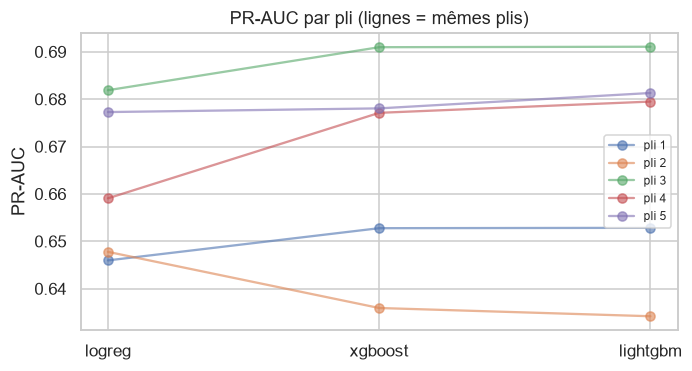

In [3]:
folds = pd.DataFrame({m: v["pr_auc"] for m, v in meta["cv"].items() if m != "dummy"})
fig, ax = plt.subplots(figsize=(7, 3.5))
for i, (_, row) in enumerate(folds.iterrows()):
    ax.plot(folds.columns, row.values, marker="o", alpha=0.6, label=f"pli {i + 1}")
ax.set_ylabel("PR-AUC"); ax.set_title("PR-AUC par pli (lignes = mêmes plis)"); ax.legend(fontsize=8)
save(fig, "03_cv_folds")
pd.DataFrame(meta["cv_paired_tests_vs_best"]).T.rename(columns={"mean_diff": "écart moyen (meilleur − autre)"})

Les courbes par pli se croisent souvent : les écarts entre modèles sont du même ordre que la
variance de la CV. Avec 5 plis, le test de Wilcoxon ne peut pas descendre sous p ≈ 0,06 :
**aucune différence n'est démontrable** entre les trois familles — seul l'écart au modèle naïf est
net. Dans ce cas, le principe de parcimonie plaide pour le modèle le plus simple et interprétable
si les scores sont équivalents.

## Évaluation finale sur le test

,roc_auc,pr_auc,brier,precision,recall,f1
logreg,0.8448,0.6518,0.1365,0.6486,0.5134,0.5731
xgboost,0.8489,0.6661,0.1344,0.6645,0.5348,0.5926
lightgbm,0.8481,0.6672,0.1344,0.6531,0.5134,0.5749
lightgbm calibré (final),0.8484,0.6681,0.1343,0.6519,0.5107,0.5727


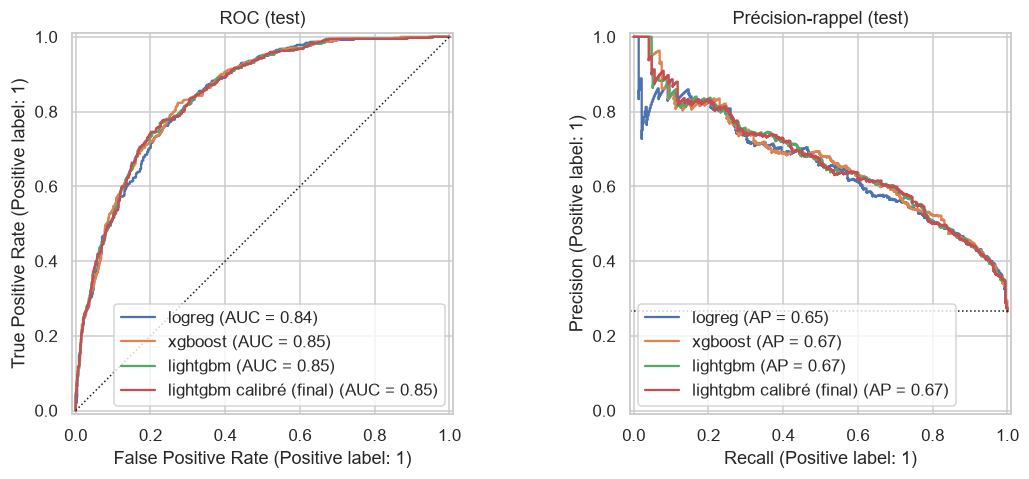

In [4]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
from churn.evaluate import classification_metrics, mcnemar_test
from churn.models import MODEL_NAMES, build_pipeline

probas = {}
for name in MODEL_NAMES:
    pipe = build_pipeline(name, meta["cv"][name]["params"]).fit(X_train, y_train)
    probas[name] = pipe.predict_proba(X_test)[:, 1]
probas[f"{meta['model_name']} calibré (final)"] = artifact["model"].predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, p in probas.items():
    RocCurveDisplay.from_predictions(y_test, p, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, p, name=name, ax=axes[1])
axes[0].plot([0, 1], [0, 1], "k:", lw=1)
axes[1].axhline(y_test.mean(), color="k", ls=":", lw=1)
axes[0].set_title("ROC (test)"); axes[1].set_title("Précision-rappel (test)")
save(fig, "03_roc_pr")

pd.DataFrame({n: classification_metrics(y_test, p, 0.5) for n, p in probas.items()}).T[
    ["roc_auc", "pr_auc", "brier", "precision", "recall", "f1"]]

In [5]:
best = meta["model_name"]
rows = {}
for other in MODEL_NAMES:
    if other != best:
        rows[f"{best} vs {other}"] = mcnemar_test(y_test, probas[best] >= 0.5, probas[other] >= 0.5)
pd.DataFrame(rows).T[["statistic", "p_value"]]

,statistic,p_value
lightgbm vs logreg,0.0135,0.9075
lightgbm vs xgboost,1.5610,0.2115


Test de McNemar sur le test : les modèles se trompent-ils sur des clients **différents** ? Une
p-value élevée confirme que, à seuil égal, leurs erreurs sont statistiquement indiscernables.

Intervalle de confiance bootstrap (1 000 rééchantillonnages) du modèle final :

In [6]:
t = meta["test"]
print(f"ROC-AUC {t['at_business_threshold']['roc_auc']:.3f}  IC95 {np.round(t['roc_auc_ci95'], 3)}")
print(f"PR-AUC  {t['at_business_threshold']['pr_auc']:.3f}  IC95 {np.round(t['pr_auc_ci95'], 3)}")

ROC-AUC 0.848  IC95 [0.826 0.868]
PR-AUC  0.668  IC95 [0.619 0.718]


## Calibration

La décision métier compare `p × gain` à un coût : elle exige des **probabilités fiables**, pas
seulement un bon classement. Le modèle final est calibré (Platt, `CalibratedClassifierCV`).

Brier non calibré 0.1344 | calibré 0.1343


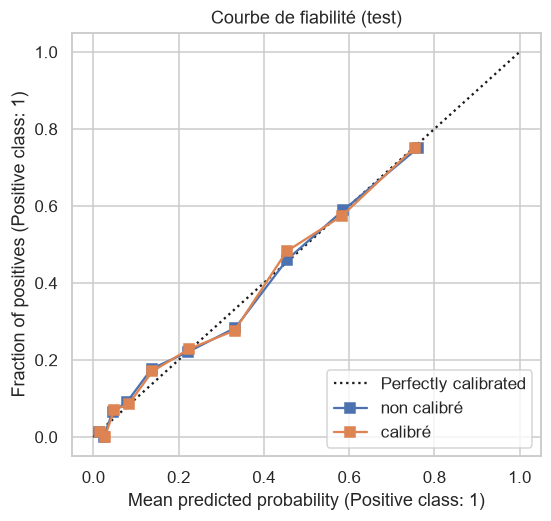

In [7]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(figsize=(5.5, 5))
raw_p = artifact["explainer_pipeline"].predict_proba(X_test)[:, 1]
cal_p = artifact["model"].predict_proba(X_test)[:, 1]
CalibrationDisplay.from_predictions(y_test, raw_p, n_bins=10, strategy="quantile", name="non calibré", ax=ax)
CalibrationDisplay.from_predictions(y_test, cal_p, n_bins=10, strategy="quantile", name="calibré", ax=ax)
ax.set_title("Courbe de fiabilité (test)")
save(fig, "03_calibration")
print(f"Brier non calibré {brier_score_loss(y_test, raw_p):.4f} | calibré {brier_score_loss(y_test, cal_p):.4f}")

Ici le gain est marginal : LightGBM optimisé sur la log-loss produit déjà des probabilités proches
de la diagonale. La calibration reste dans le pipeline final : c'est une assurance peu coûteuse,
et indispensable si l'on passe à un modèle mal calibré (ex. `class_weight="balanced"`).

## Interprétabilité

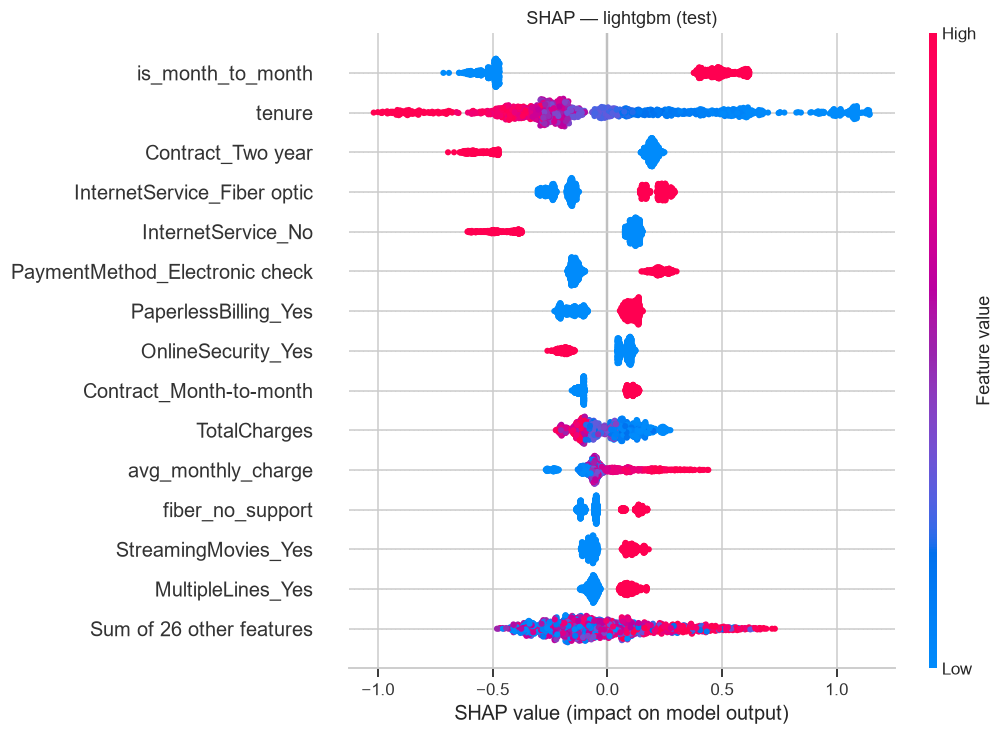

In [8]:
import shap

pipe = artifact["explainer_pipeline"]
Xt = pipe[:-1].transform(X_test)
Xt.columns = Xt.columns.str.replace(r"^(num|cat)__", "", regex=True)
est = pipe[-1]
explainer = shap.LinearExplainer(est, artifact["background"]) if hasattr(est, "coef_") else shap.TreeExplainer(est)
sv = explainer(Xt)
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.title(f"SHAP — {best} (test)")
save(plt.gcf(), "03_shap_beeswarm")
plt.show()

In [9]:
# Comparaison avec l'autre famille (linéaire vs arbres) : s'appuient-elles sur les mêmes signaux ?
other = "logreg" if best != "logreg" else "xgboost"
other_pipe = build_pipeline(other, meta["cv"][other]["params"]).fit(X_train, y_train)
Xt_other = other_pipe[:-1].transform(X_test)
Xt_other.columns = Xt_other.columns.str.replace(r"^(num|cat)__", "", regex=True)
bg = other_pipe[:-1].transform(X_train.sample(100, random_state=SEED))
bg.columns = Xt_other.columns
other_explainer = (shap.LinearExplainer(other_pipe[-1], bg) if other == "logreg"
                   else shap.TreeExplainer(other_pipe[-1]))
sv_other = other_explainer(Xt_other)

imp = pd.DataFrame({
    best: pd.Series(np.abs(sv.values).mean(0), index=Xt.columns),
    other: pd.Series(np.abs(sv_other.values).mean(0), index=Xt_other.columns),
})
imp = imp.div(imp.sum()).sort_values(best, ascending=False).head(15)
print("Corrélation de Spearman des importances :", round(imp.corr(method="spearman").iloc[0, 1], 2))
imp

Corrélation de Spearman des importances : 0.65


,lightgbm,logreg
is_month_to_month,0.1609,0.0890
tenure,0.1291,0.1128
Contract_Two year,0.0900,0.0401
InternetService_Fiber optic,0.0673,0.0920
InternetService_No,0.0625,0.0644
PaymentMethod_Electronic check,0.0552,0.0068
PaperlessBilling_Yes,0.0406,0.0343
OnlineSecurity_Yes,0.0362,0.0455
Contract_Month-to-month,0.0356,0.0011
TotalCharges,0.0320,0.0010


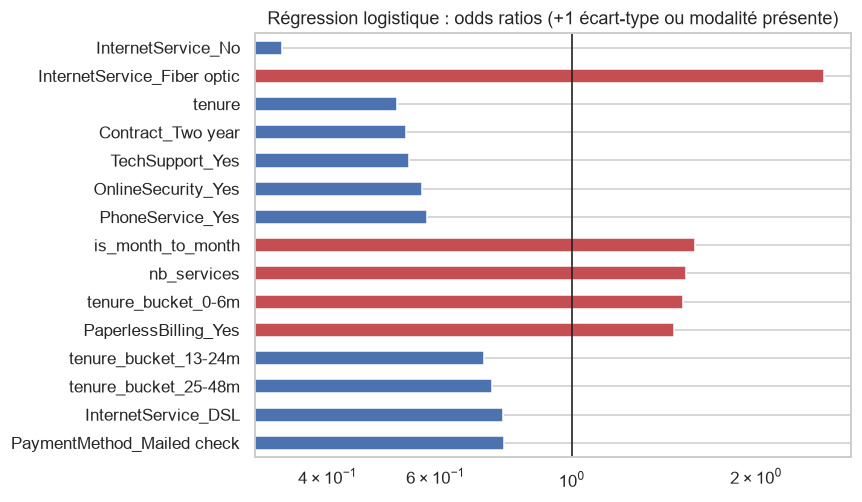

In [10]:
# Lecture directe de la régression logistique : odds ratios.
logreg = build_pipeline("logreg", meta["cv"]["logreg"]["params"]).fit(X_train, y_train)
names = logreg[:-1].get_feature_names_out()
coefs = pd.Series(logreg[-1].coef_[0], index=pd.Index(names).str.replace(r"^(num|cat)__", "", regex=True))
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15)
odds = np.exp(top)
fig, ax = plt.subplots(figsize=(7, 5))
odds[::-1].plot.barh(ax=ax, color=["#C44E52" if v > 1 else "#4C72B0" for v in odds[::-1]])
ax.axvline(1, color="k", lw=1); ax.set_xscale("log")
ax.set_title("Régression logistique : odds ratios (+1 écart-type ou modalité présente)")
save(fig, "03_odds_ratios")

Modèle linéaire et modèle d'arbres mettent en avant les mêmes leviers : **contrat mensuel, faible
ancienneté, fibre sans services de protection, paiement par chèque électronique**. La cohérence
entre un modèle linéaire et un modèle d'arbres renforce la confiance dans ces explications.